In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")



In [6]:
df=pd.read_csv('cluster_1.csv')

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [23]:
print("Dimensiune DataFrame:", df.shape)

Dimensiune DataFrame: (1359, 12)


Setul  de date are 1359 linii si 12 coloane.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [12]:
df.nunique() 

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

In [13]:
# Verificarea valorilor lipsă 
missing_values =df.isna().sum()
if missing_values.sum() > 0:
    print("Valori lipsă pe coloană:")
    print(missing_values[missing_values > 0])
else:
    print("Nu există valori lipsă în setul de date.")

Nu există valori lipsă în setul de date.


In [14]:
print("Rânduri dublicate:", df.duplicated().sum())

Rânduri dublicate: 240


In [17]:
df=df.drop_duplicates()

In [18]:
print("Rânduri dublicate:", df.duplicated().sum())

Rânduri dublicate: 0


Am eliminat valorile duplicate

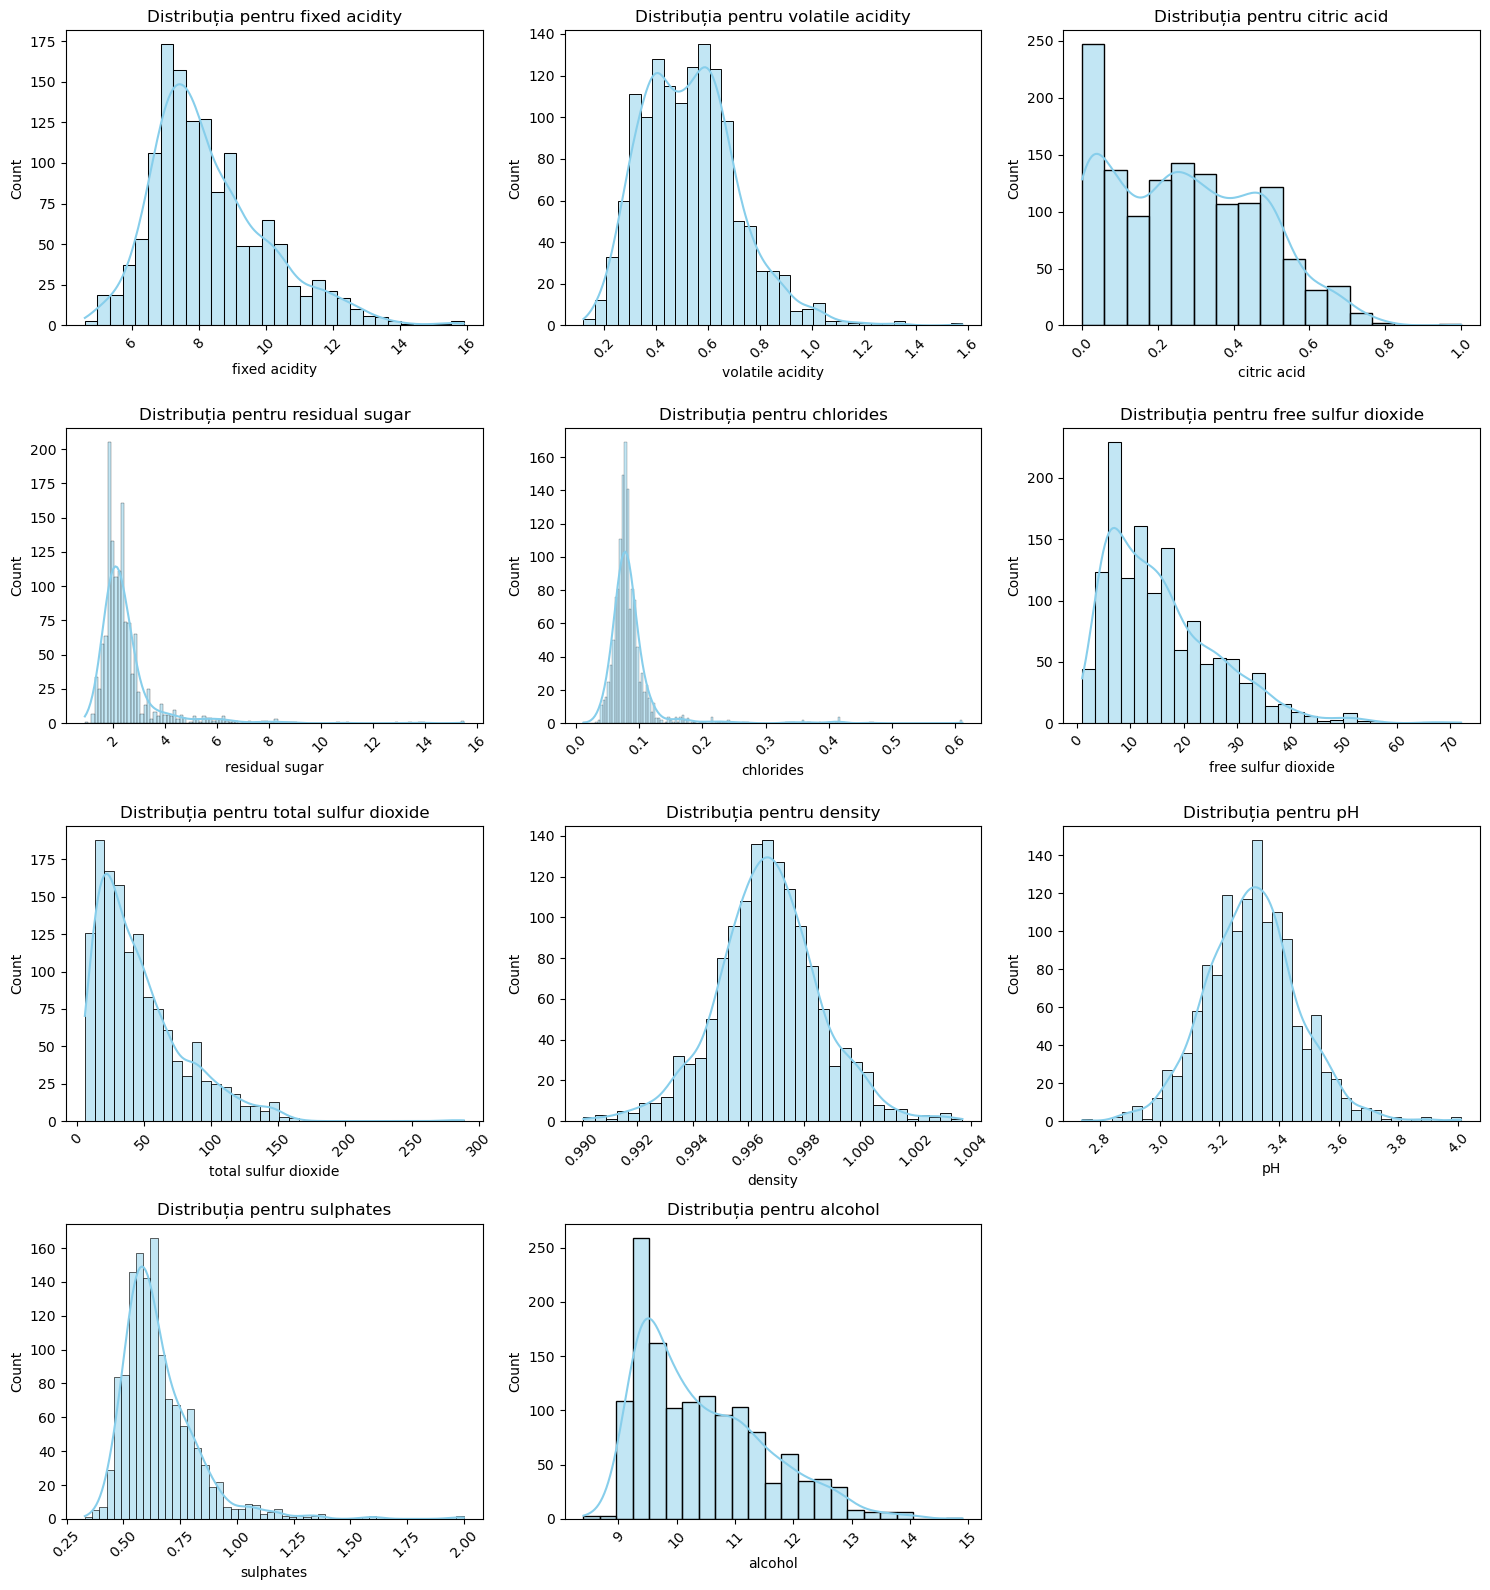

In [21]:
# Distribuția tuturor variabilelor

# Selectarea coloanelor numerice
df_plot=df.drop('quality', axis=1)
num_cols = df_plot.select_dtypes(include=[np.number]).columns

# Setare subgraficului
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

# Creare distplot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.histplot(df_plot[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribuția pentru {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Ascunderea subploturilor goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Dicționar pentru a stoca numărul de outlieri per coloană
outliers_dict = {}

for col in df.drop('quality', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers.shape[0]

# Afișăm numărul de outlieri pentru fiecare coloană
outliers_series = pd.Series(outliers_dict).sort_values(ascending=False)
print("Numărul de outlieri per coloană (sortat descrescător):")
print(outliers_series)


Numărul de outlieri per coloană (sortat descrescător):
residual sugar          126
chlorides                87
sulphates                55
total sulfur dioxide     45
fixed acidity            41
density                  35
pH                       28
free sulfur dioxide      26
volatile acidity         19
alcohol                  12
citric acid               1
dtype: int64


Toate variabilele au valori extreme

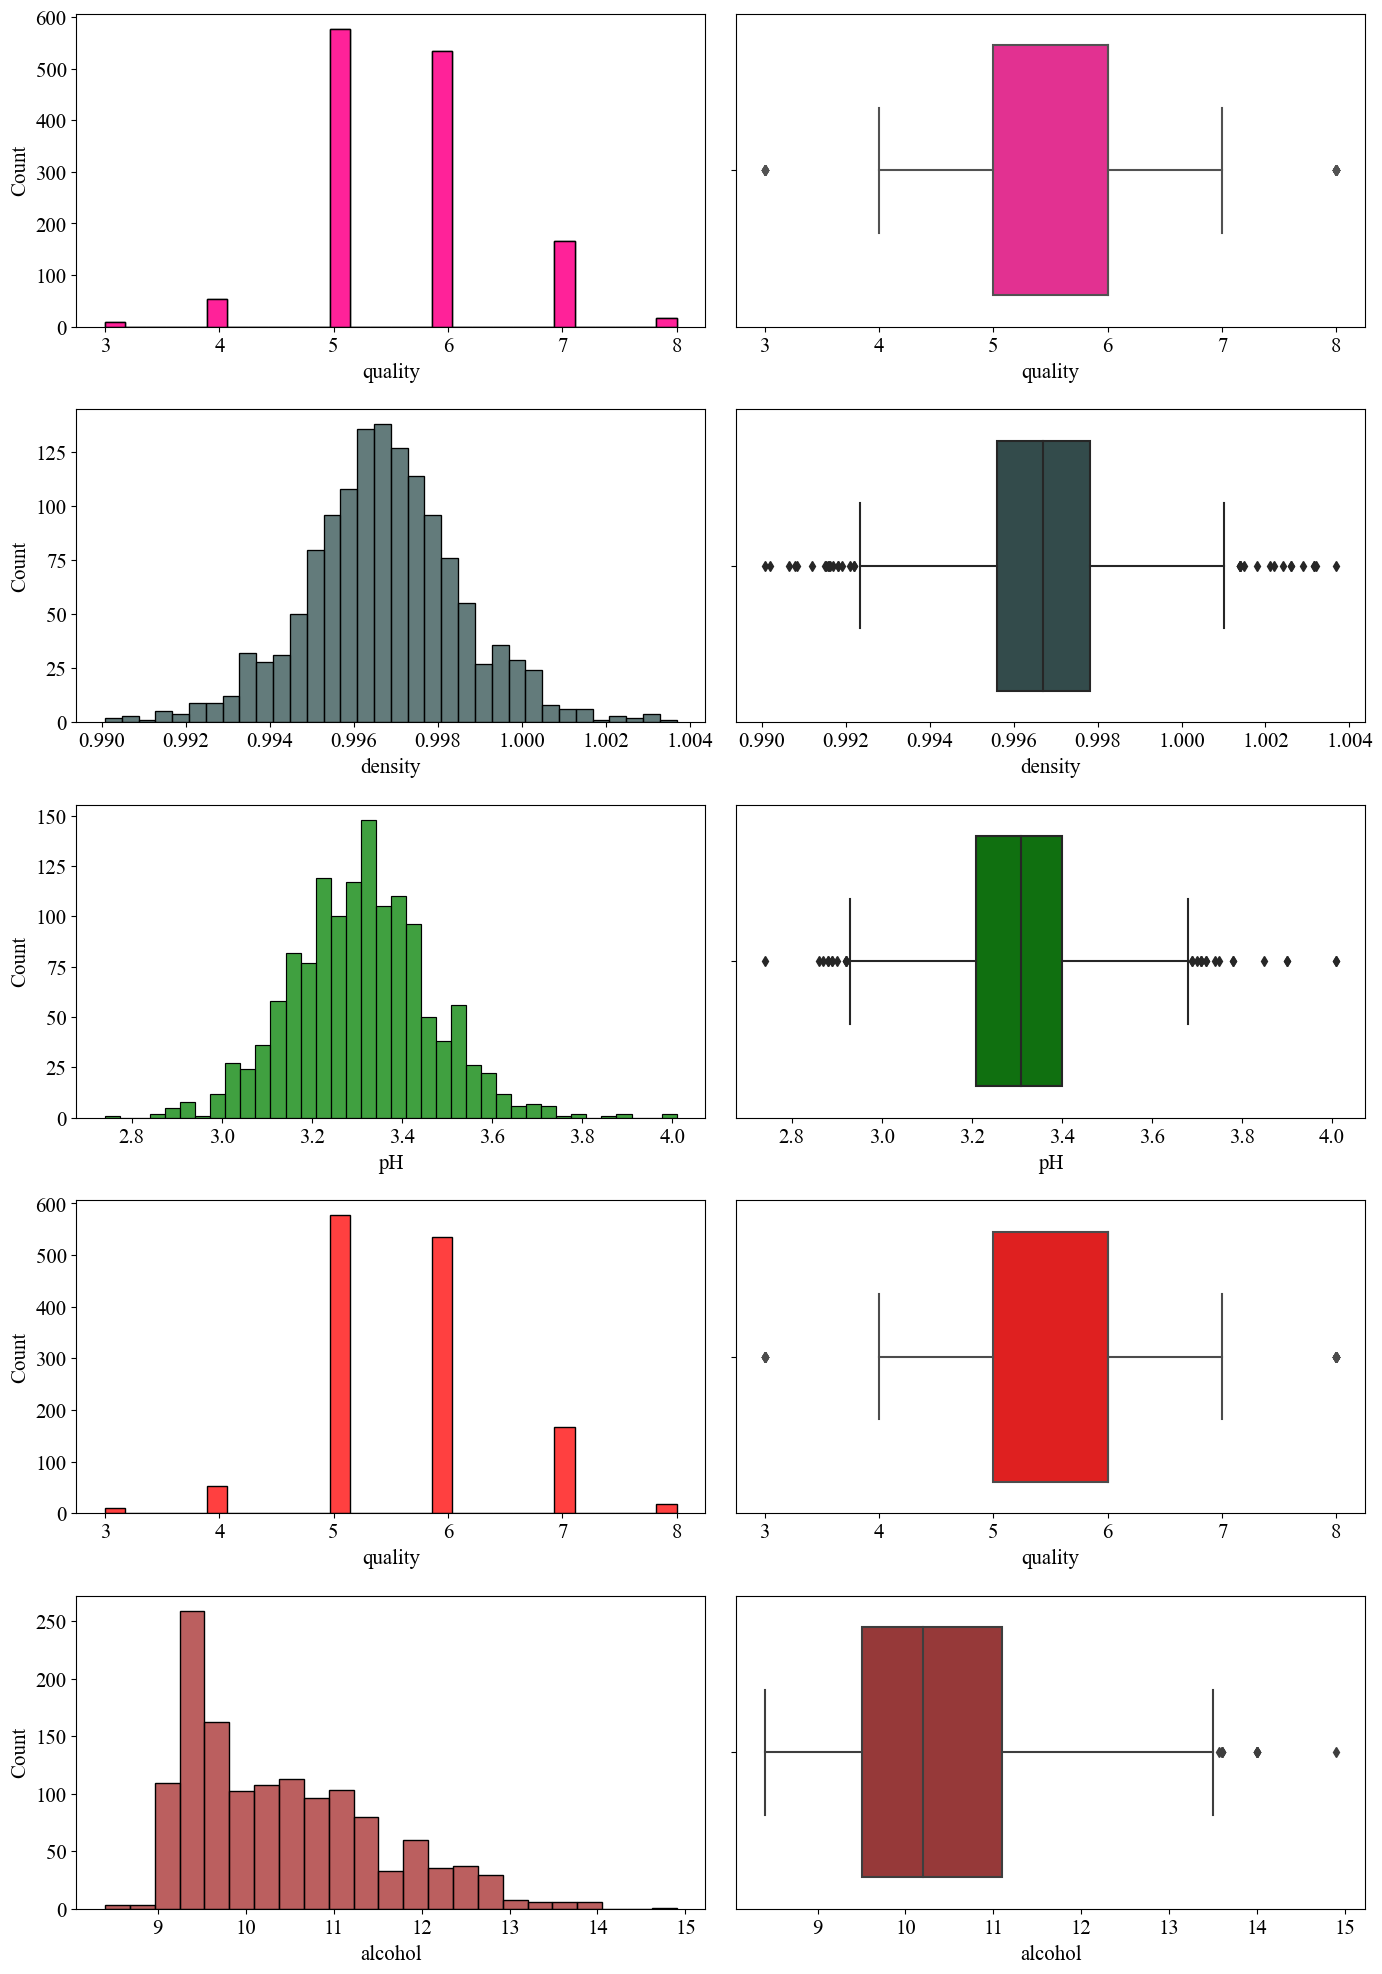

In [25]:
plt.rcParams['figure.figsize'] = (14, 20)   # dimensiunea figurii
plt.rcParams['font.size'] = 15              # dimensiunea fontului
plt.rcParams['font.family'] = 'Times New Roman' # fontul figurii
plt.rcParams['axes.unicode_minus'] = False  # pentru a afișa corect semnul minus

# -----------------------------
# Histograme și boxplot-uri pentru variabile numerice
# -----------------------------
plt.subplot(5,2,1)
sns.histplot(df['quality'], color='DeepPink') # Subplot rând 1, coloană 1
sns.histplot(df['quality'], color='DeepPink')  # Histogramă pentru distribuția vârstei
plt.subplot(5,2,2)                        # Subplot rând 1, coloană 2
sns.boxplot(x=df['quality'], color='DeepPink') # Boxplot pentru identificarea outlierilor

plt.subplot(5,2,3)
sns.histplot(x=df['density'], color='DarkSlateGray')
plt.subplot(5,2,4)
sns.boxplot(x=df['density'], color='DarkSlateGray')

plt.subplot(5,2,5)
sns.histplot(df['pH'], color='Green')
plt.subplot(5,2,6)
sns.boxplot(x=df['pH'], color='Green')

plt.subplot(5,2,7)
sns.histplot(df['quality'], color='Red')
plt.subplot(5,2,8)
sns.boxplot(x=df['quality'], color='Red')

plt.subplot(5,2,9)
sns.histplot(df['alcohol'], color='Brown')
plt.subplot(5,2,10)
sns.boxplot(x=df['alcohol'], color='Brown')

# Ajustare layout-ul pentru a nu se suprapune graficele
plt.tight_layout()

# Afișarea graficelor
plt.show()

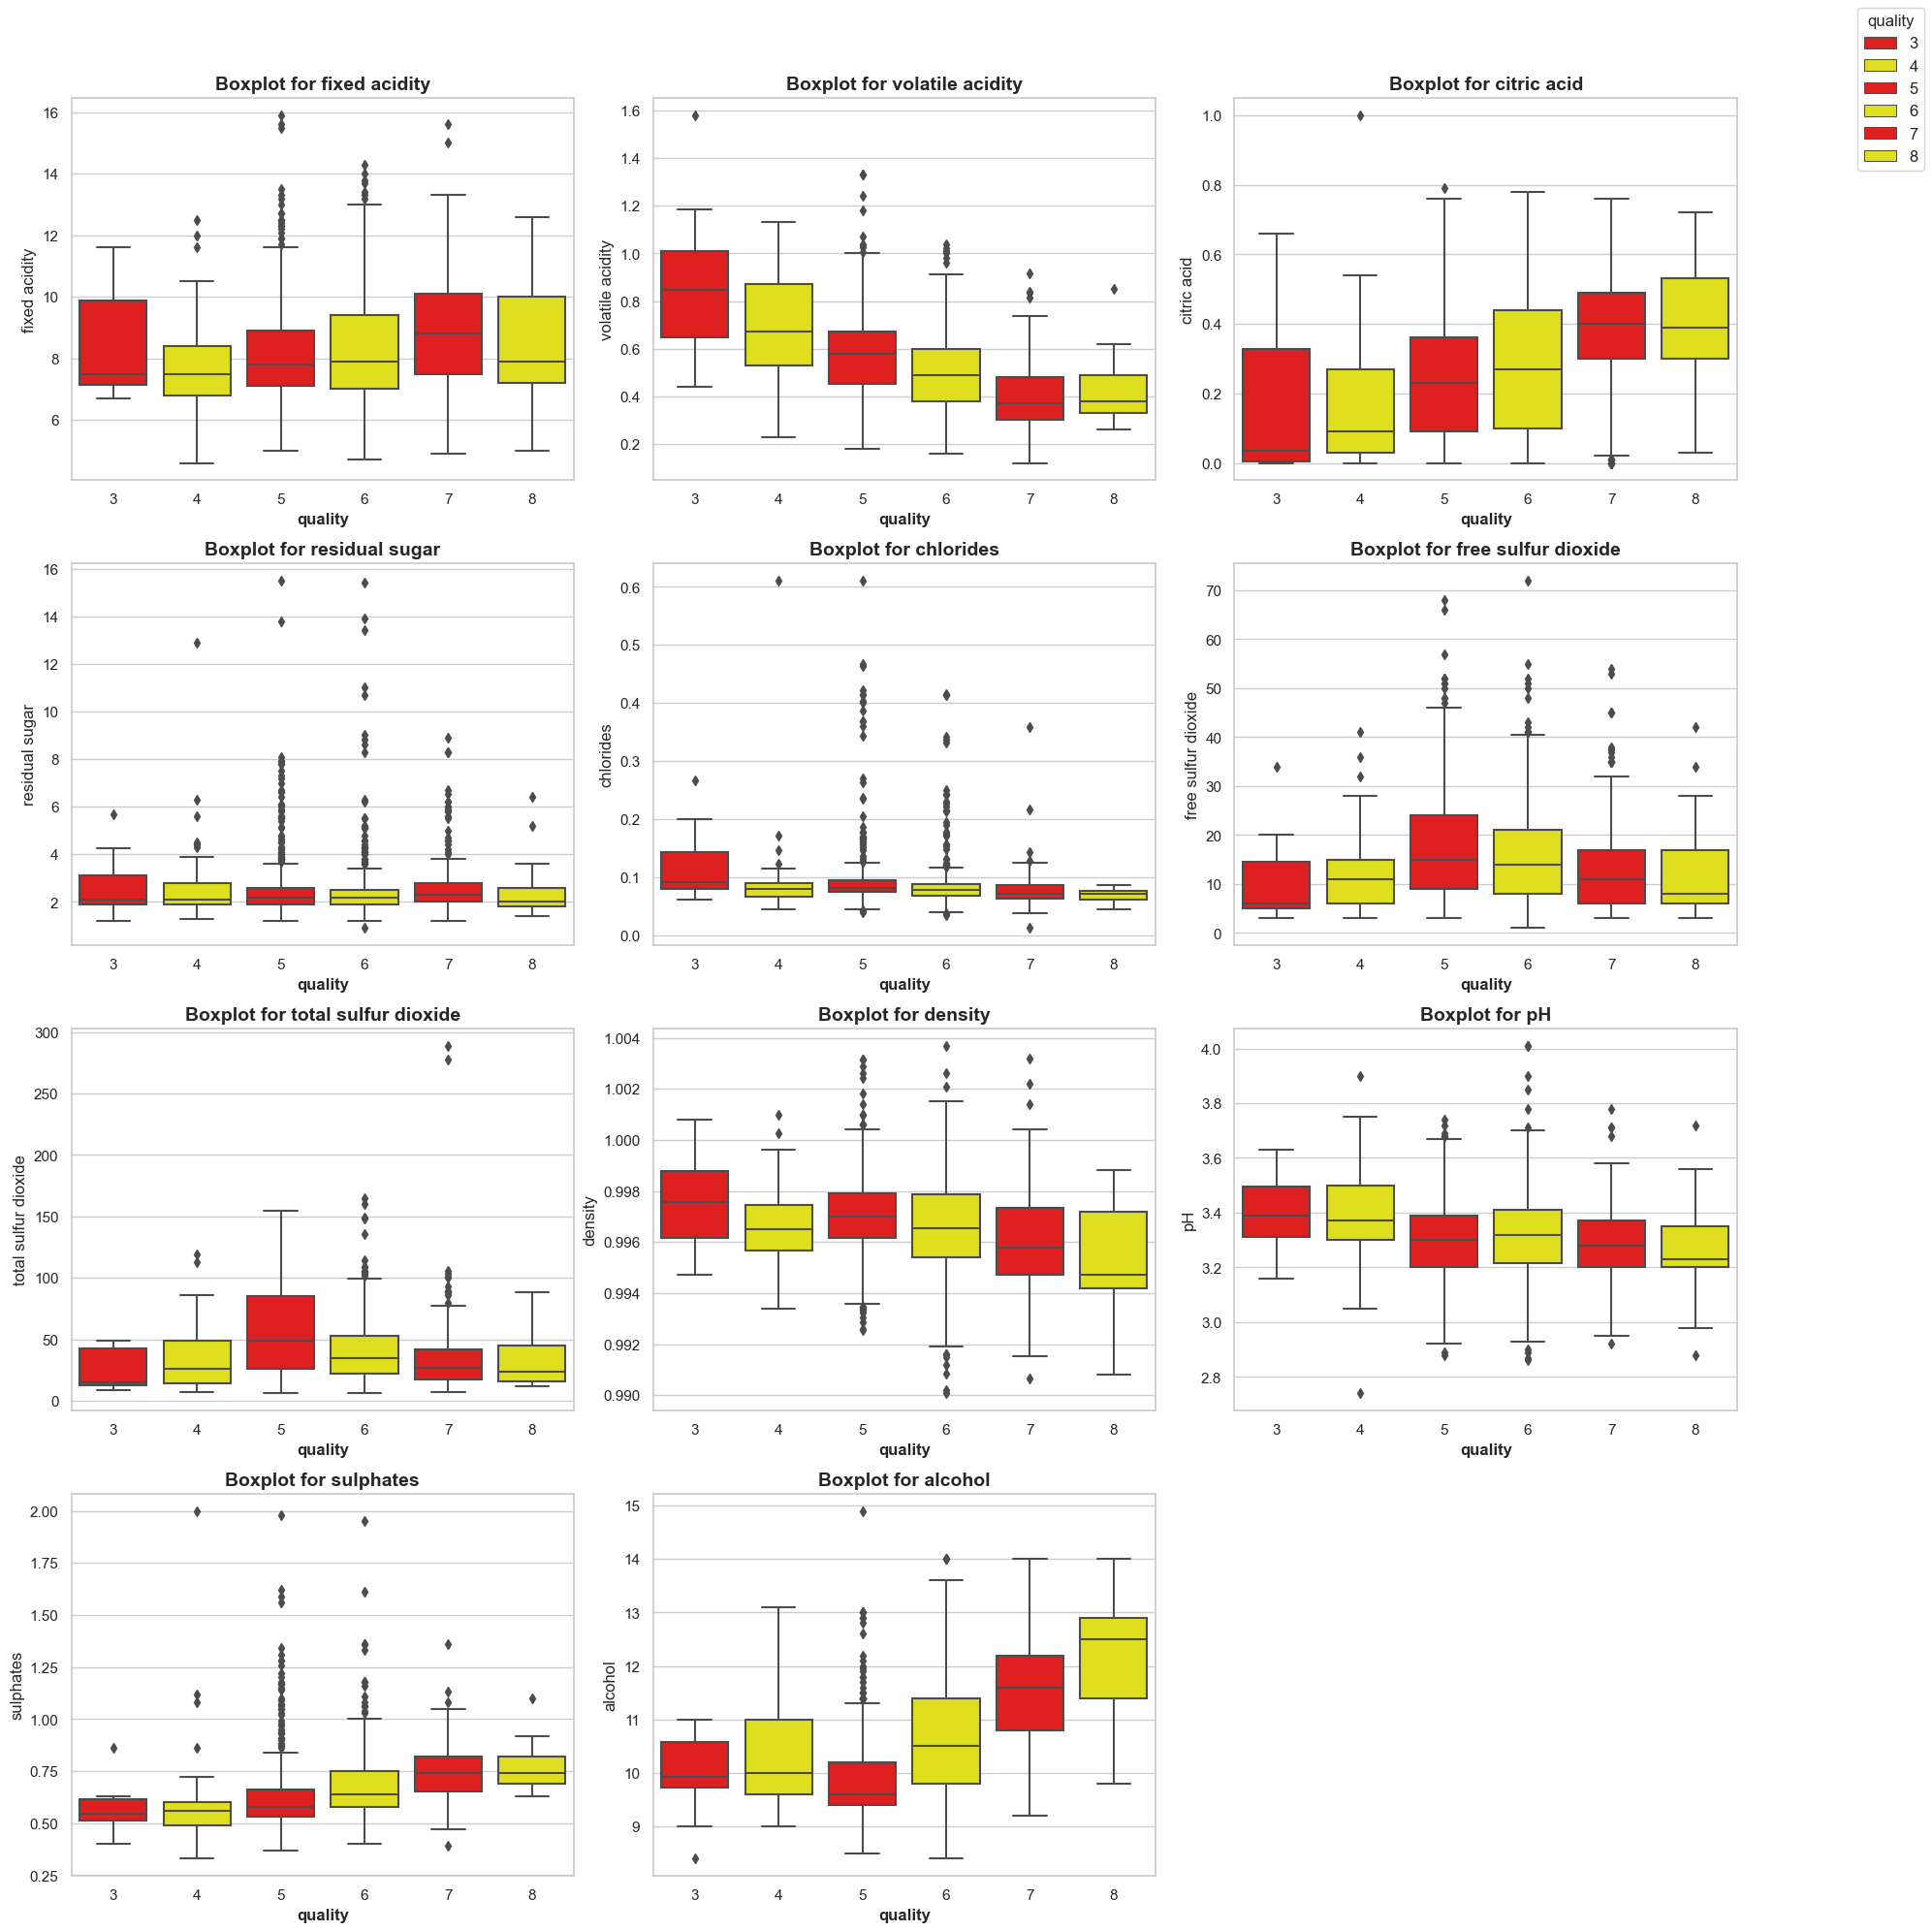

In [30]:
sns.set(style="whitegrid")

# Selectăm coloanele numerice dorite
columns = df.drop('quality', axis=1).columns

# Setăm grid-ul de subplot-uri
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(x='quality', y=col, hue='quality', data=df,
                palette=['red', 'yellow'], dodge=False, ax=axes[i])
    axes[i].set_xlabel('quality', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f'Boxplot for {col}', fontsize=14, fontweight='bold')
    
    # Verificăm dacă legenda există înainte să o eliminăm
    legend = axes[i].get_legend()
    if legend is not None:
        legend.remove()

# Creăm o legendă comună pentru întregul figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='quality', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()

In [26]:
# Selectarea coloanelor numerice 
numerical = df.select_dtypes(include=['number']).columns.tolist()

# Selectarea coloanele categorice (de tip obiect) 
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Afișarea rezultatelor
print('Coloane numerice:', numerical)
print('Coloane categorice:', categorical)

for col in df[categorical]:
    # Afișarea numărului de apariții pentru fiecare valoare unică
    print(f"Distribuția pentru coloana '{col}':")
    print(df[col].value_counts())
    
    # Separator vizual
    print("====="*5)

Coloane numerice: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Coloane categorice: []


Setul de date nu are coloane categoriale, deci nu se va transforma nimic.

In [27]:
df.shape

(1359, 12)

In [34]:
def clasificare(x):
    if 0 <= x <= 4:
        return 0
    elif 5 <= x <= 7:
        return 1
    elif 8 <= x <= 10:
        return 2
    else:
        return 0

df['target'] = df['quality'].apply(clasificare)

In [36]:
df=df.drop('quality',axis=1)

In [28]:
from sklearn.preprocessing import StandardScaler
X=df.drop('quality',axis=1)
X_scaled = StandardScaler().fit_transform(X)

In [29]:
X_scaled 

array([[-0.52443096,  0.93200015, -1.39325797, ...,  1.29187216,
        -0.57856134, -0.95437429],
       [-0.29406274,  1.91580043, -1.39325797, ..., -0.70839548,
         0.12482157, -0.5845748 ],
       [-0.29406274,  1.25993358, -1.18861732, ..., -0.32124691,
        -0.05102416, -0.5845748 ],
       ...,
       [-1.38831178,  0.11216658, -0.88165635, ...,  1.35639693,
         0.59374351,  0.7097234 ],
       [-1.38831178,  0.63139451, -0.77933603, ...,  1.67902074,
         0.3006673 , -0.21477532],
       [-1.33071973, -1.19956712,  1.01126962, ...,  0.51757501,
         0.00759108,  0.52482366]])

In [32]:
y=df['quality']

In [33]:
df.shape

(1359, 12)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


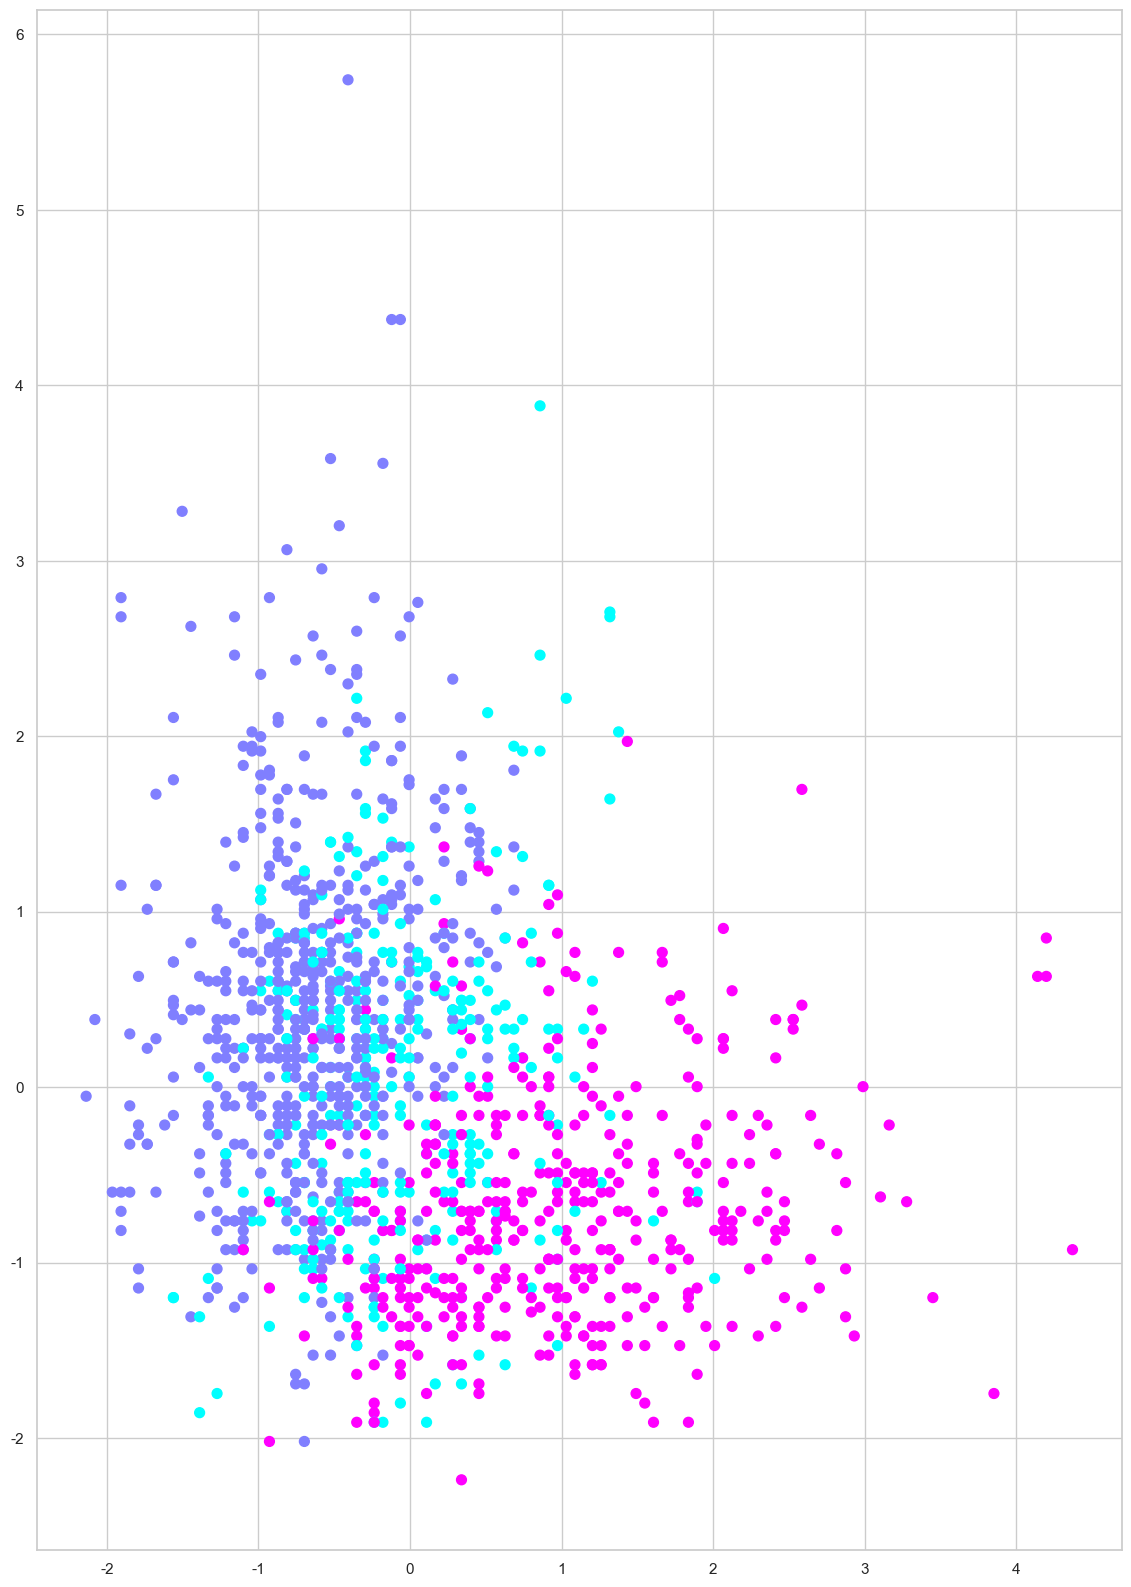

In [51]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, s=50, cmap='cool')

In [52]:
from sklearn.metrics import adjusted_rand_score
ari=adjusted_rand_score(y, y_kmeans)
print(ari)

0.03512497666966783


In [66]:
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, y_kmeans)
print(sil)

0.18775370669728167


In [54]:
from sklearn.metrics import fowlkes_mallows_score
fmi = fowlkes_mallows_score(y, y_kmeans)
print(fmi)

0.3764087989425647


Am ales sa folosesc 3 clustere. Scorul Silhouette a fost de 0.187 ceea ce indica o potrivire moderata (coeficientul variază între -1 și 1 la scorul Silhouette, unde 1 indică un cluster bine separat și compact, iar -1 indică un clustering incorect).
valorile ARI și FM obținute sunt  asemanatoare si mai aproapiate de 0, indica o potrivire slaba spre moderata

Text(0.5, 1.0, 'DBSCAN pe setul de date')

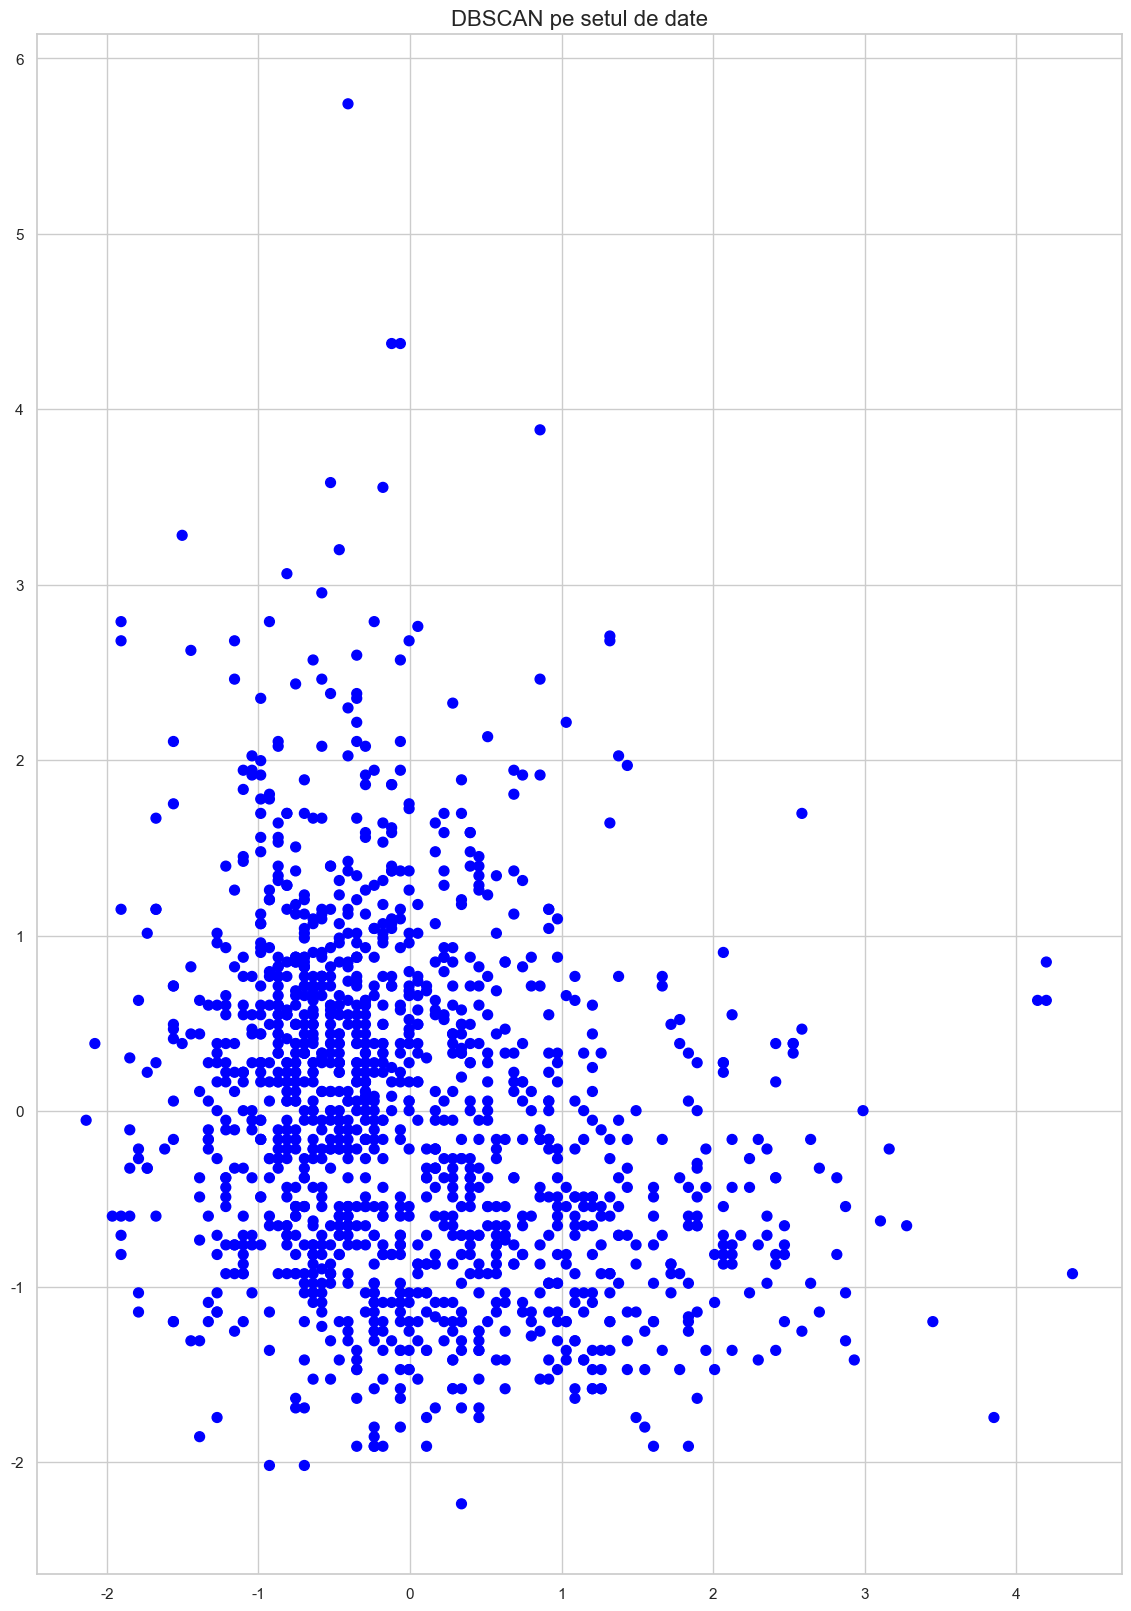

In [56]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_db = dbscan.fit_predict(X_scaled)


plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_db, s=50, cmap='brg')
plt.title("DBSCAN pe setul de date", fontsize=16)

Vizual, clusterele formate de DBSCAN si de la K-Means sunt asemanatoare

In [57]:
from sklearn.metrics import adjusted_rand_score
aridb=adjusted_rand_score(y, y_db)
print(aridb)

0.0


In [58]:
from sklearn.metrics import fowlkes_mallows_score
fmdb = fowlkes_mallows_score(y, y_db)
print(fmdb)

0.5929570679605742


Scorul ARI de la DB  este mai bun

Text(0.5, 1.0, ' pe setul de date')

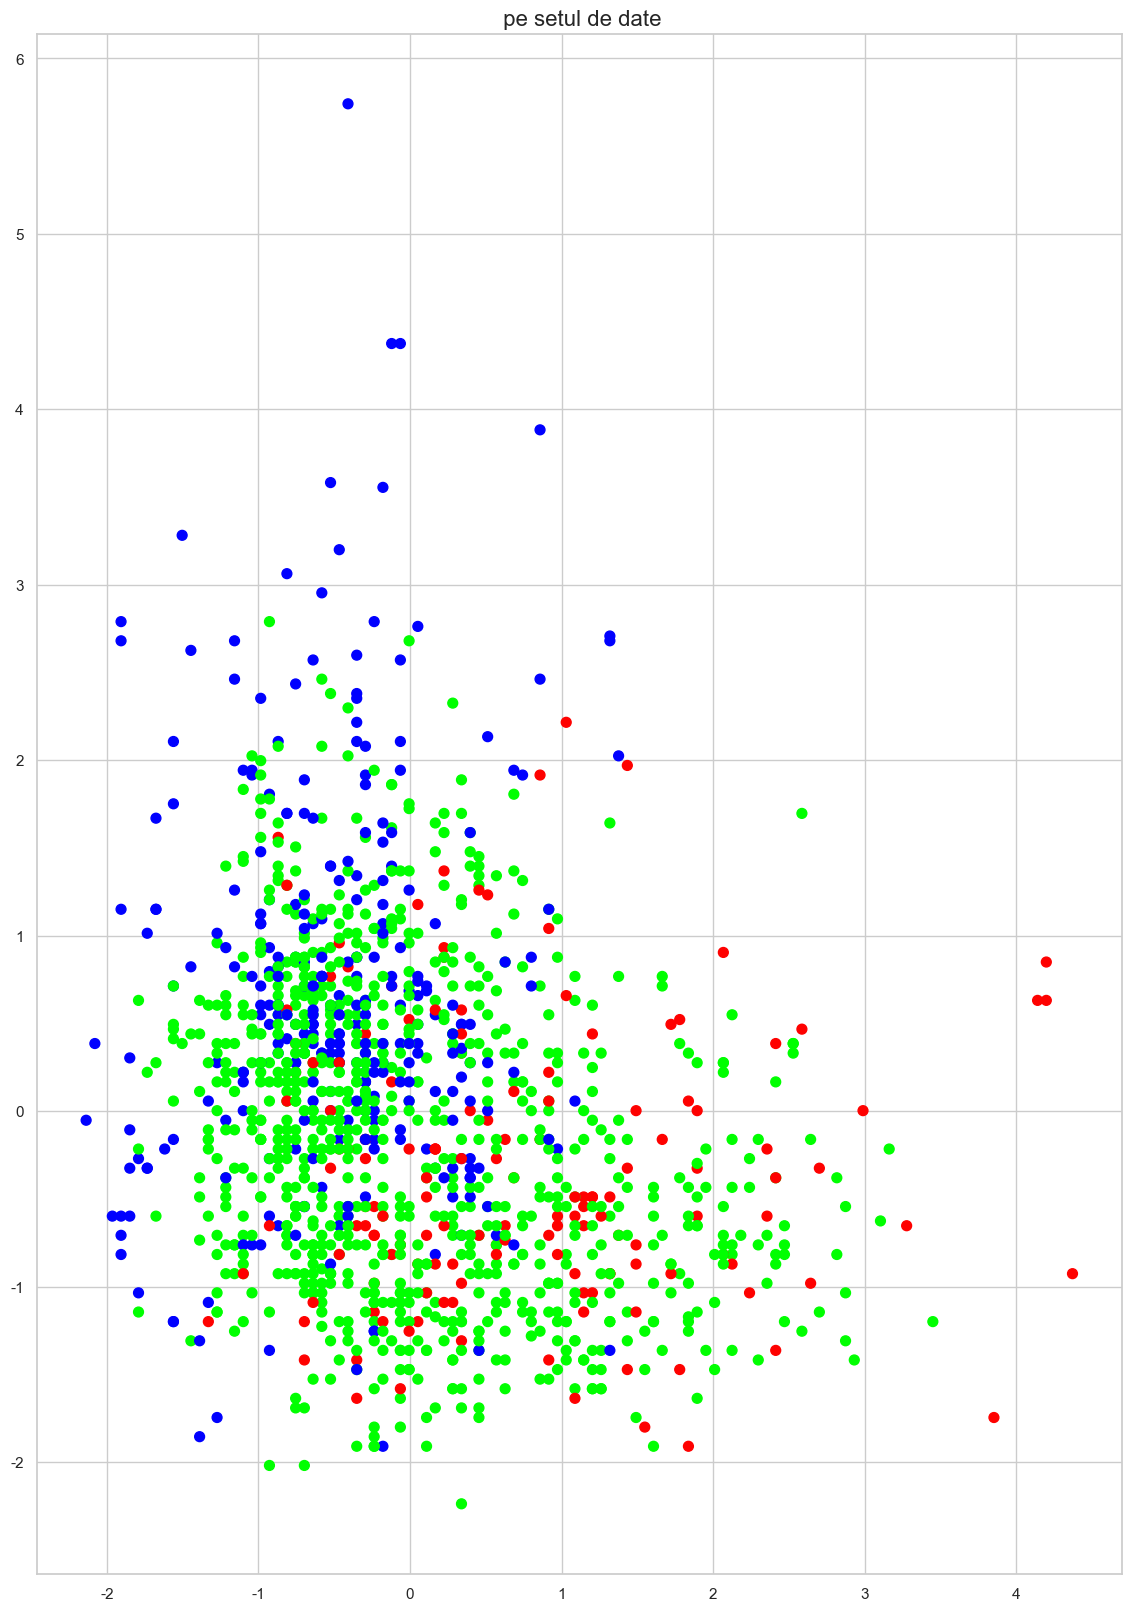

In [60]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
y_gmm = gmm.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_gmm, s=50, cmap='brg')
plt.title(" pe setul de date", fontsize=16)

Vizual, clusterele formate de GMM si cele de la K-Means sunt asemanatoare

In [61]:
from sklearn.metrics import adjusted_rand_score
arigmm=adjusted_rand_score(y, y_gmm)
print(arigmm)

0.021992660704633966


Rezultatul ARI este putin mai slab decât la K-Means

In [62]:
from sklearn.metrics import silhouette_score
silgmm = silhouette_score(X_scaled, y_gmm)
print(silgmm)

0.11828661456245462


In [63]:
from sklearn.metrics import fowlkes_mallows_score
fmgmm = fowlkes_mallows_score(y, y_gmm)
print(fmgmm)

0.43472837196424324


In [68]:

results = pd.DataFrame({
    'Metrica/Algoritm': ['ARI', 'Silhouette', 'FM'],
    'Kmeans': [ari, sil, fmi],
    'DBSCAN': [aridb, np.NAN, fmdb],
    'Gaussian Mixture': [arigmm, silgmm, fmgmm]
})

results

,Metrica/Algoritm,Kmeans,DBSCAN,Gaussian Mixture
0,ARI,0.035125,0.000000,0.021993
1,Silhouette,0.187754,NaN,0.118287
2,FM,0.376409,0.592957,0.434728


Algoritmul care oferă cea mai clară separare a clusterelor pe acest set de date este K-means.


Algoritmul care a obținut cel mai mare scor ARI este K-means, iar algoritmul care a obținut cel mai mare scor FM este DBSCAN.